In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import find_peaks

# Regression and graph functions

In [3]:
def fit_stokes_from_window(theta_rad, I_theta):
    """
    Reconstruct the Stokes vector from one angular/temporal window.

    The measured curve is fitted to the harmonic model:

        I(theta) = a0 + a2*sin(2theta) + a4c*cos(4theta) + a4s*sin(4theta)

    and the Stokes parameters are recovered through:

        S1 = 4 a4c
        S2 = 4 a4s
        S3 = -2 a2
        S0 = 2 a0 - 2 a4c

    Parameters
    ----------
    theta_rad : array
        QWP angles inside the selected window.
    I_theta : array
        Intensity values measured in the same window.

    Returns
    -------
    S_fit : ndarray
        Reconstructed Stokes vector [S0, S1, S2, S3].
    coeffs : ndarray
        Fitted harmonic coefficients [a0, a2, a4c, a4s].
    """
    # Build the linear design matrix for least-squares fitting
    A = np.column_stack([
        np.ones_like(theta_rad),
        np.sin(2.0 * theta_rad),
        np.cos(4.0 * theta_rad),
        np.sin(4.0 * theta_rad),
    ])


    # Solve the linear least-squares problem
    coeffs, *_ = np.linalg.lstsq(A, I_theta, rcond=None)
    a0, a2, a4c, a4s = coeffs

    # Convert harmonic coefficients into the Stokes parameters
    S1 = 4.0 * a4c
    S2 = 4.0 * a4s
    S3 = -2.0 * a2
    S0 = 2.0 * a0 - 2.0 * a4c

    return np.array([S0, S1, S2, S3]), coeffs

In [4]:
def normalize_stokes(S):
    """
    Normalize the Stokes vector and compute the degree of polarization.

    Parameters
    ----------
    S : array-like
        Stokes vector [S0, S1, S2, S3].

    Returns
    -------
    s : ndarray
        Normalized Stokes vector [s1, s2, s3].
    dop : float
        Degree of polarization.
    """
    S0, S1, S2, S3 = S
    s = np.array([S1 / S0, S2 / S0, S3 / S0])
    dop = np.sqrt(S1**2 + S2**2 + S3**2) / S0
    return s, dop

In [5]:
def poincare_sphere_graph(s):
    theta = np.linspace(0,np.pi,100)
    phi = np.linspace(0,2*np.pi,100)
    theta, phi = np.meshgrid(theta, phi)

    x = np.cos(phi)*np.sin(theta)
    y = np.sin(phi)*np.sin(theta)
    z = np.cos(theta)

    fig = plt.figure(figsize=(10,10))
    ax = fig.add_subplot(projection='3d')
    ax.set_box_aspect([1,1,1])

    ax.plot_surface(x,y,z,alpha = 0.25)
    ax.plot(np.cos(phi),np.sin(phi),0,color = 'black')
    ax.plot(0,np.cos(phi),np.sin(phi),color = 'black')
    #ax.plot(np.cos(phi),0,np.sin(phi),color = 'black')


    arrow = ax.quiver(0,0,0,s[0],s[1],s[2],color = 'red', arrow_length_ratio=0.1)
    ax.scatter(0,0,0, c = 'black')

    ax.text(0,0,1.2,'Right')
    ax.text(1.2,0,0.2,'Diagonal')
    ax.text(-1.2,0,0.2,'Anti-Diagonal')
    ax.text(0,0,-1.3,'Left')
    ax.text(0,-1.2,0,'Horizontal')
    ax.text(0,1.2,0,'Vertical')
    ax.set_title(f'S = ({s[0].round(2)},{s[1].round(2)},{s[2].round(2)})')
    ax.set_xlabel(r'$S_1$')
    ax.set_ylabel(r'$S_2$')
    ax.set_zlabel(r'$S_3$')


# Manual measurements

In [6]:
# --- Offset voltage to correct for the dark current of the photodetector ---
offset = 0.00182 

# --- Load the measurement data, apply the voltage offset, and convert angles to radians ---
medicion = pd.read_csv('Measurements/medicion_manual_v0.1.csv')
medicion['voltaje'] = (medicion['voltaje'] - offset)
medicion['rad'] = medicion['angulo']*np.pi/180
medicion.head()

,angulo,voltaje,rad
0,0,0.034577,0.000000
1,2,0.032154,0.034907
2,4,0.028125,0.069813
3,6,0.024189,0.104720
4,8,0.021522,0.139626


In [7]:
# --- Identify peaks in the voltage data to select the mean as the normalization factor ---
peaks_volt = find_peaks(medicion['voltaje'])[0]
peaks_angle = medicion['rad'][peaks_volt]
norm_number = medicion['voltaje'][peaks_volt].mean()
display(f'Normalization number: {norm_number}')


'Normalization number: 0.04687499999999992'

In [8]:
# --- Normalize the voltage data by the mean of the identified peaks ---
medicion['voltaje_norm'] = (medicion['voltaje'])/ norm_number
medicion.head()

,angulo,voltaje,rad,voltaje_norm
0,0,0.034577,0.000000,0.737638
1,2,0.032154,0.034907,0.685943
2,4,0.028125,0.069813,0.599996
3,6,0.024189,0.104720,0.516028
4,8,0.021522,0.139626,0.459145


In [9]:
# --- Prepare the data range for fitting the Stokes parameters ---
range = (medicion['rad'].iloc[0] <= medicion['rad']) & (medicion['rad'] <= medicion['rad'].iloc[-1])

# --- Fit the Stokes parameters from the normalized voltage data ---
S, coeffs = fit_stokes_from_window(medicion['rad'][range], medicion['voltaje_norm'][range])

# --- Normalize the Stokes vector and compute the degree of polarization ---
s, dop = normalize_stokes(S)

print('Stokes vector (S0, S1, S2, S3): ', S)
print('-----------------------------')
print('Normalized Stokes vector (s1, s2, s3): ', s)
print('-----------------------------')
print('Degree of polarization: ', dop)


Stokes vector (S0, S1, S2, S3):  [ 0.66587721  0.72339348 -1.79723402 -0.0344931 ]
-----------------------------
Normalized Stokes vector (s1, s2, s3):  [ 1.08637669 -2.6990472  -0.051801  ]
-----------------------------
Degree of polarization:  2.909940454307127


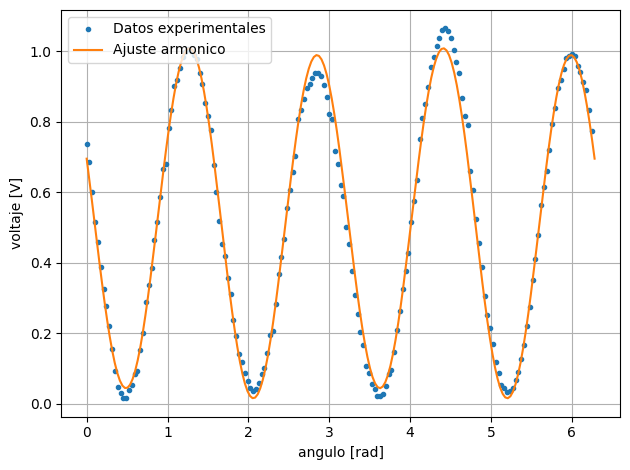

In [10]:
# --- Create a curve from the fitted coefficients to compare with the experimental data ---
theta = np.linspace(0,2*np.pi,200)
I = lambda a0, a2, a4c, a4s, theta: a0 + a2*np.sin(2*theta) + a4c*np.cos(4*theta) + a4s*np.sin(4*theta)

# --- Plot the experimental data and the fitted curve ---
plt.figure()
plt.plot(medicion['rad'][range], medicion['voltaje_norm'][range],'.',label = 'Datos experimentales')
plt.plot(theta, I(*coeffs, theta),'-', label = 'Ajuste armonico')

plt.legend(loc = 'upper left')
plt.xlabel('angulo [rad]')
plt.ylabel('voltaje [V]')
plt.grid()
plt.tight_layout()

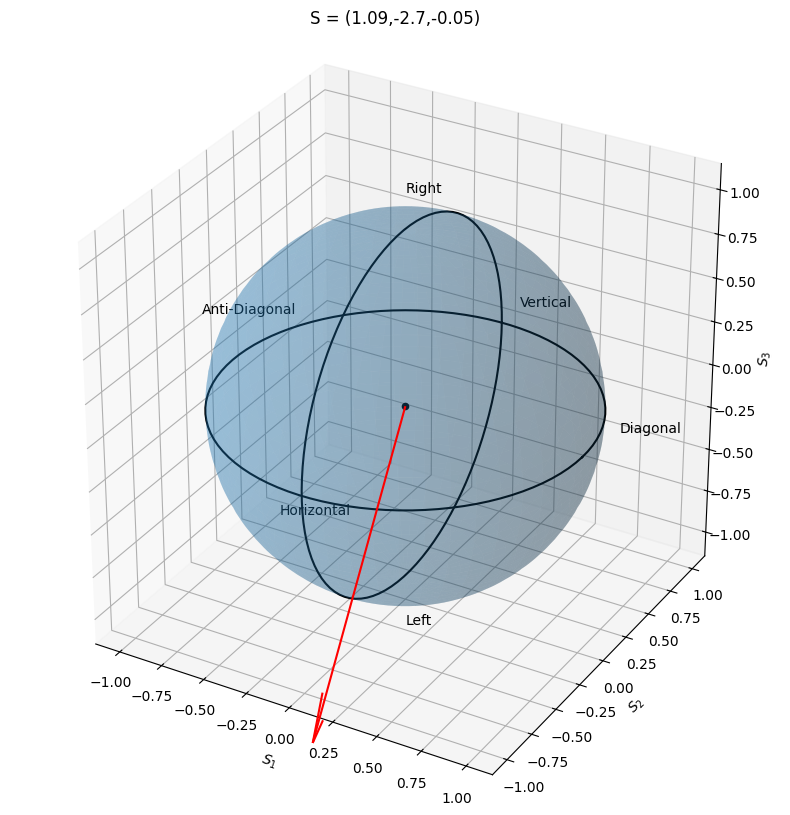

In [11]:
# --- Poincare sphere graph of the normalized Stokes vector ---
poincare_sphere_graph(s)

# Tests

## Test 1: many regressions, in different windows of the data 

In [12]:
# --- Prepare the different windows for fitting the Stokes parameters ---
ranges = [(0.5 <= medicion['rad']) & (medicion['rad'] <= 2),
          (2 <= medicion['rad']) & (medicion['rad'] <= 3.5),
          (3.5 <= medicion['rad']) & (medicion['rad'] <= 5),
          (5 <= medicion['rad']) & (medicion['rad'] <= 6.5)]

# --- Fit the Stokes parameters from the normalized voltage data and normalize the Stokes vector, for every window---
S_test_1 = []
s_test_1 = []
for i in ranges:
    S_test_1.append(fit_stokes_from_window(medicion['rad'][i], medicion['voltaje_norm'][i])[0])
    s_test_1.append(normalize_stokes(S_test_1[-1])[0])

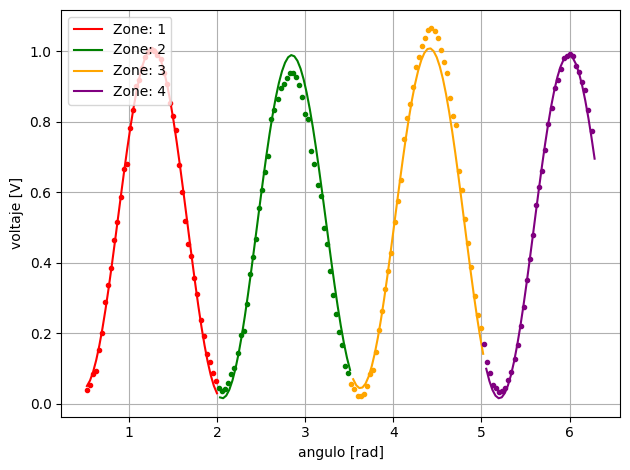

In [13]:
# --- Create a curve from the fitted coefficients to compare with the experimental data ---
theta = np.linspace(0,2*np.pi,180)
I = lambda a0, a2, a4c, a4s, theta: a0 + a2*np.sin(2*theta) + a4c*np.cos(4*theta) + a4s*np.sin(4*theta)

# --- Plot the experimental data and the fitted curve, for every window ---
colors = ['blue', 'red', 'green', 'orange', 'purple']
n = 1

plt.figure()
for i in ranges:    
    plt.plot(medicion['rad'][i], medicion['voltaje_norm'][i],'.',color = colors[n])
    plt.plot(theta[i], I(*coeffs, theta)[i],'-',color = colors[n], label = f'Zone: {n}')
    n += 1

plt.legend(loc = 'upper left')
plt.xlabel('angulo [rad]')
plt.ylabel('voltaje [V]')
plt.grid()
plt.tight_layout()

In [14]:
# --- Calculate the mean of the normalized Stokes vector from the different windows ---
s_1 = (s_test_1[0][0] + s_test_1[1][0] + s_test_1[2][0] + s_test_1[3][0])/4
s_2 = (s_test_1[0][1] + s_test_1[1][1] + s_test_1[2][1] + s_test_1[3][1])/4
s_3 = (s_test_1[0][2] + s_test_1[1][2] + s_test_1[2][2] + s_test_1[3][2])/4

s_mean = np.array([s_1, s_2, s_3])

print(f'Mean of the normalized Stokes vector from the different windows (s1_mean, s2_mean, s3_mean): {s_mean}')

Mean of the normalized Stokes vector from the different windows (s1_mean, s2_mean, s3_mean): [ 1.04107157e+00 -2.64208502e+00 -2.26748946e-03]


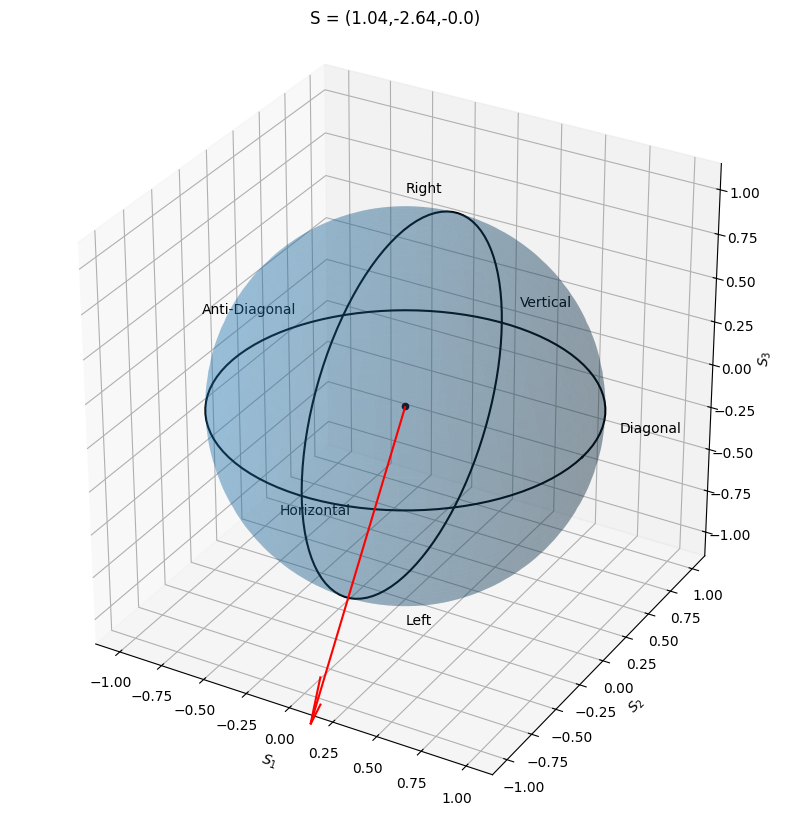

In [15]:
# --- Poincare sphere graph of the mean normalized Stokes vector from the different windows ---
poincare_sphere_graph(s_mean)

## Test 2: different stokes vector normalization

Degree of polarization from the regression: 2.909940454307127


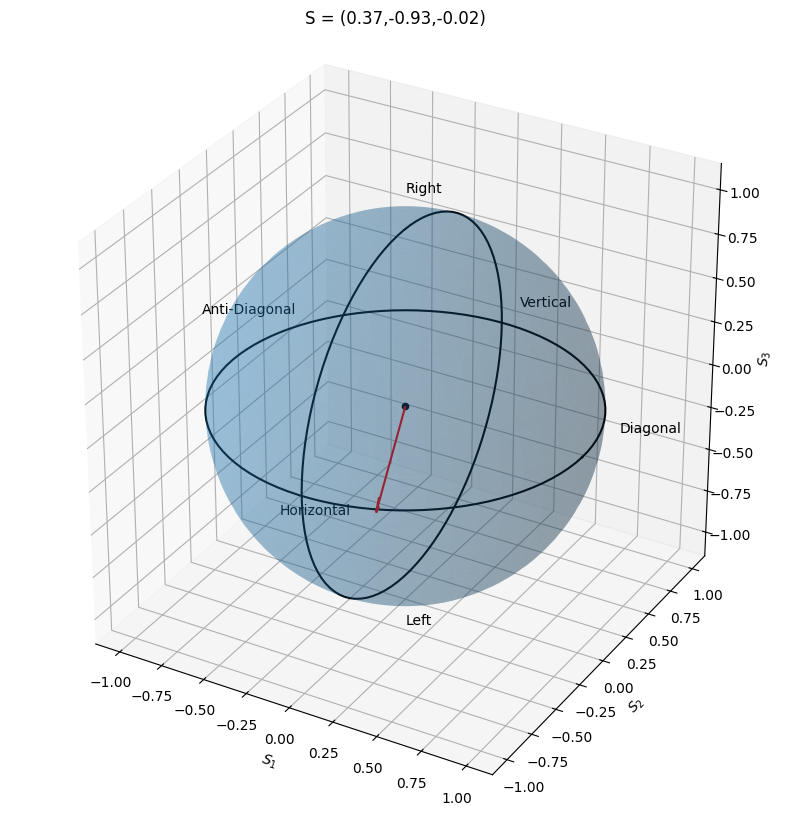

In [16]:
# --- Normalize the Stokes vector dividing by not normalized stokes vector norm ---
s_test_2 = S[1:] / np.sqrt(S[1]**2 + S[2]**2 + S[3]**2)

# --- Print the dop of the regression ---
dop_test_2 = np.sqrt(S[1]**2 + S[2]**2 + S[3]**2) / S[0]
print(f'Degree of polarization from the regression: {dop_test_2}')

# --- Poincare sphere graph of the normalized Stokes vector ---
poincare_sphere_graph(s_test_2)

## Test 3: Regression with inverted function

In [23]:
# --- Prepare the data range for fitting the Stokes parameters ---
range = (medicion['rad'].iloc[0] <= medicion['rad']) & (medicion['rad'] <= medicion['rad'].iloc[-1])

# --- Fit the Stokes parameters from the normalized voltage data ---
S, coeffs = fit_stokes_from_window(medicion['rad'][range], -medicion['voltaje_norm'][range] + 1)

# --- Normalize the Stokes vector and compute the degree of polarization ---
s_test_3, dop_test_3 = normalize_stokes(S)

print('Stokes vector (S0, S1, S2, S3): ', S)
print('-----------------------------')
print('Normalized Stokes vector (s1, s2, s3): ', s)
print('-----------------------------')
print('Degree of polarization: ', dop)


Stokes vector (S0, S1, S2, S3):  [ 1.33412279 -0.72339348  1.79723402  0.0344931 ]
-----------------------------
Normalized Stokes vector (s1, s2, s3):  [ 1.08637669 -2.6990472  -0.051801  ]
-----------------------------
Degree of polarization:  2.909940454307127


Degree of polarization from the regression: 1.4523873286614497


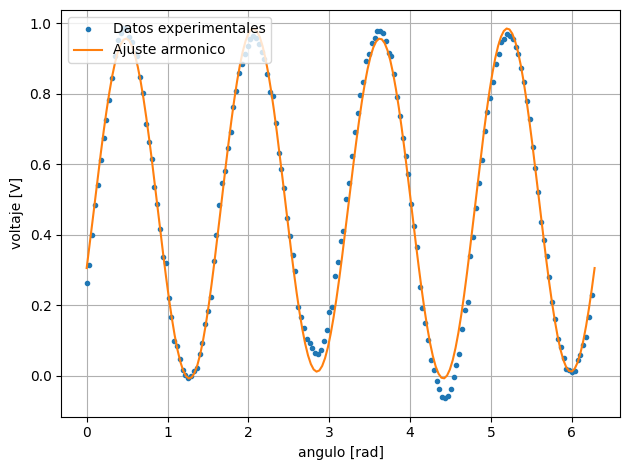

In [ ]:
# --- Plot the experimental data and the fitted curve ---
plt.figure()
plt.plot(medicion['rad'][range], -medicion['voltaje_norm'][range] + 1,'.',label = 'Datos experimentales')
plt.plot(theta, I(*coeffs, theta),'-', label = 'Ajuste armonico')

plt.legend(loc = 'upper left')
plt.xlabel('angulo [rad]')
plt.ylabel('voltaje [V]')
plt.grid()
plt.tight_layout()

Degree of polarization from the regression: 1.4523873286614497


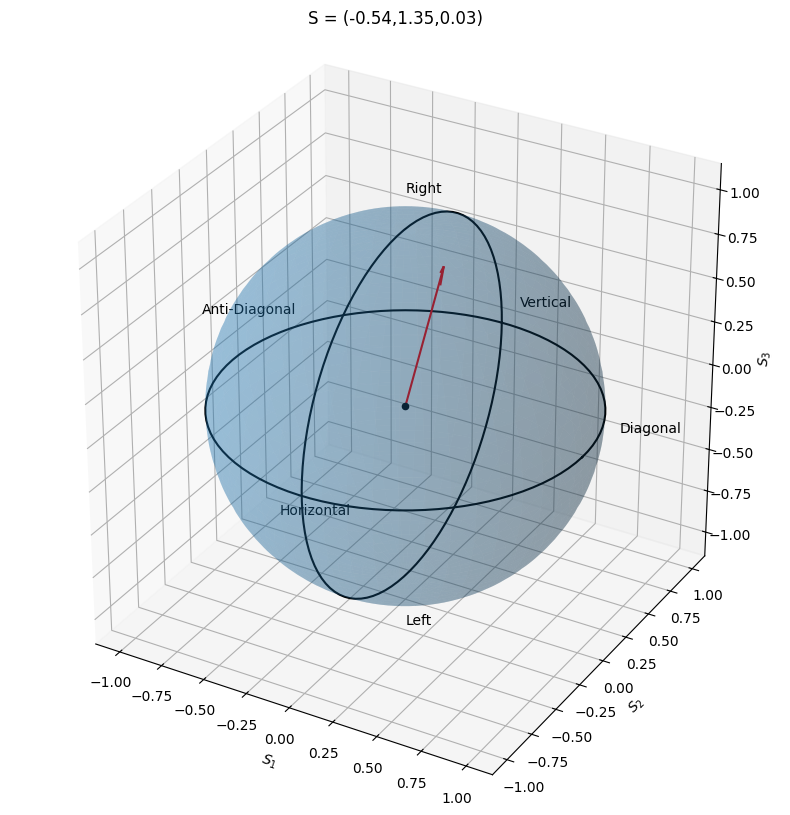

In [28]:
# --- Print the dop of the regression ---
dop_test_3 = np.sqrt(S[1]**2 + S[2]**2 + S[3]**2) / S[0]
print(f'Degree of polarization from the regression: {dop_test_3}')

# --- Poincare sphere graph of the normalized Stokes vector ---
poincare_sphere_graph(s_test_3)
